In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
data_dir = os.getcwd() + '/data/'

data_100C = np.loadtxt(data_dir + '20190619/total_100C.CSV', delimiter=';')
data_250C = np.loadtxt(data_dir + '20190619/total_250C.CSV', delimiter=';')
data_350C = np.loadtxt(data_dir + '20190619/total_350C.CSV', delimiter=';')
data_ox_sub = np.loadtxt(data_dir + '20190619/si_ox_substrate.CSV', delimiter=';')
data_sub = np.loadtxt(data_dir + '20190619/si_wafer.CSV', delimiter=';')
data_empty = np.loadtxt(data_dir + '20190619/empty_bg.CSV', delimiter=';')

## Transmittances

Text(0, 0.5, 'Transmittance (%)')

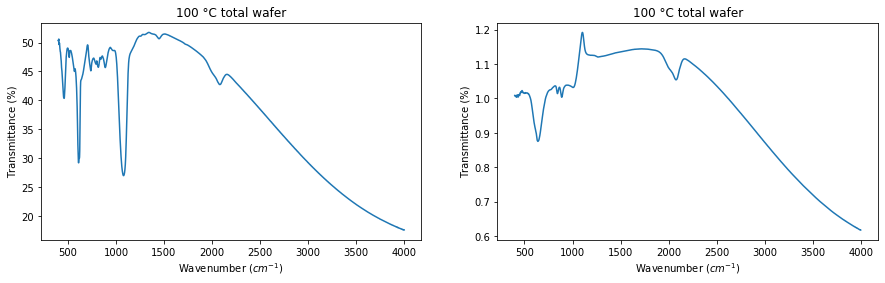

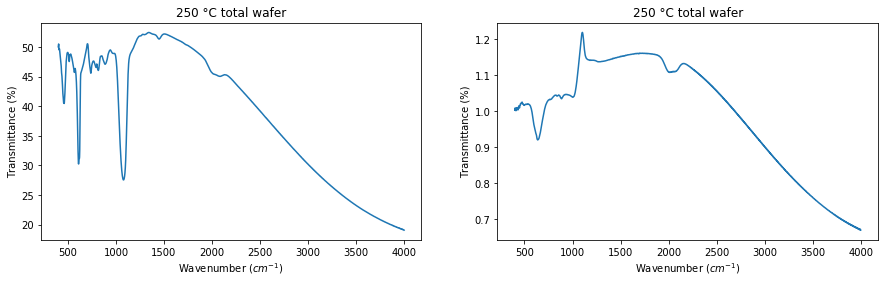

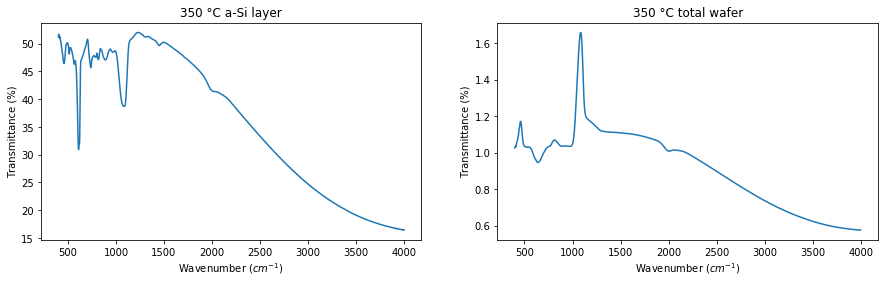

In [4]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(data_100C[:,0], data_100C[:,1])
ax1.set_title("100 °C total wafer")
ax1.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Transmittance (%)')
ax2.plot(data_100C[:,0], data_100C[:,1]/data_ox_sub[:,1])
ax2.set_title("100 °C total wafer")
ax2.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Transmittance (%)')

fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(data_250C[:,0], data_250C[:,1])
ax1.set_title("250 °C total wafer")
ax1.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Transmittance (%)')
ax2.plot(data_250C[:,0], data_250C[:,1]/data_ox_sub[:,1])
ax2.set_title("250 °C total wafer")
ax2.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Transmittance (%)')

fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(data_350C[:,0], data_350C[:,1])
ax1.set_title("350 °C a-Si layer")
ax1.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Transmittance (%)')
ax2.plot(data_350C[:,0], data_350C[:,1]/data_ox_sub[:,1])
ax2.set_title("350 °C total wafer")
ax2.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Transmittance (%)')

## Data analysis

R: 0.4900906469796629
C: 0.29039444303874606


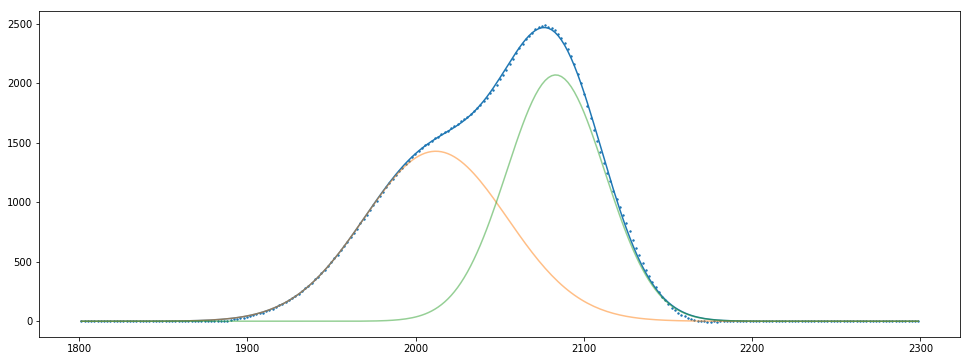

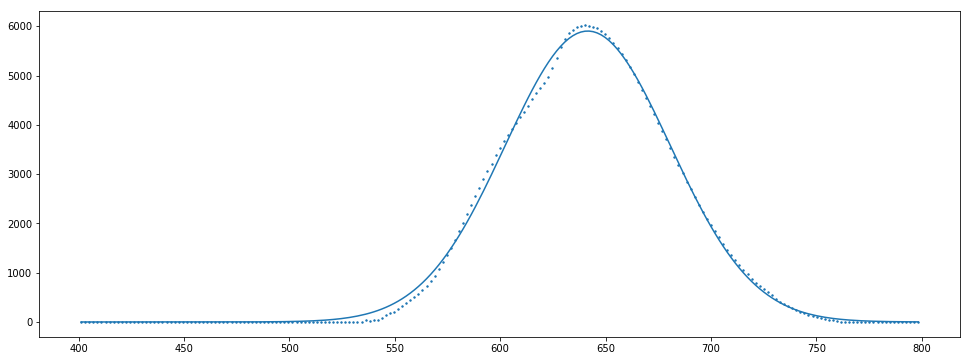

In [4]:
from FTIR_fitting import fit_FTIR
data100 = data_100C
data100[:,1] = data_100C[:,1]/data_ox_sub[:,1]*100
fit_FTIR(data100, 253)

R: 0.32805584690453915
C: 0.2172970424061768


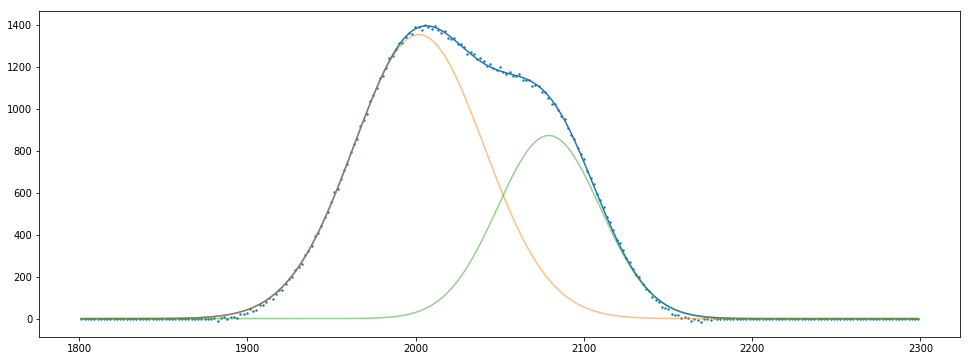

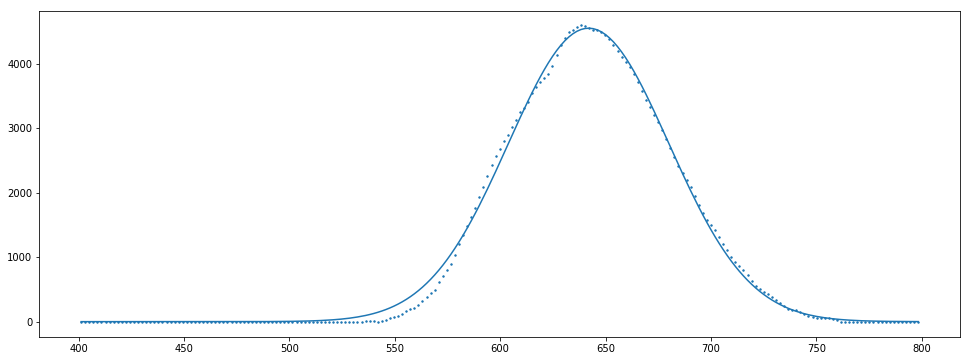

In [5]:
from FTIR_fitting import fit_FTIR
data250 = data_250C
data250[:,1] = data_250C[:,1]/data_ox_sub[:,1]*100
fit_FTIR(data250, 237)

R: 0.11372321436092486
C: 0.16840643879033998


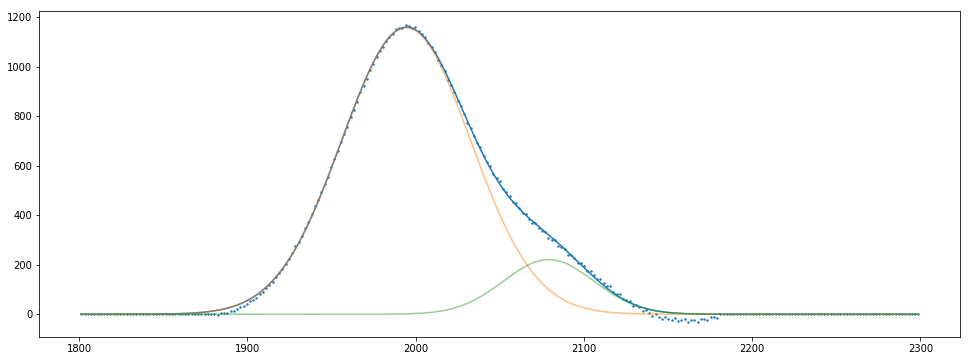

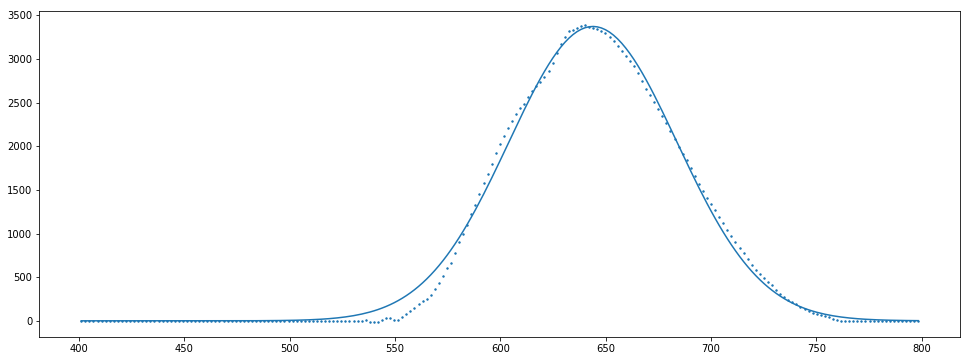

In [9]:
from FTIR_fitting import fit_FTIR
data350 = data_350C
data350[:,1] = data_350C[:,1]/data_ox_sub[:,1]*100
fit_FTIR(data_350C, 261)

In [17]:
np.max(data_sub[:,1])

52.93135

In [66]:
import numpy as np
from scipy.optimize import curve_fit
T0 = 0.54
t = 237

Tmeas = 0.5

p0 = 1e-3
def T(t,a):
    return 4*T0**2*np.exp(-a*t)/((1+T0)**2 - (1-T0)**2 * np.exp(-2*a*t))

popt, pcov = curve_fit(T, t, Tmeas, p0=p0)

absorbance = np.log10(1/Tmeas)
absorption_coeff = 2.303*absorbance/t

In [67]:
popt[0]

0.00027458492249956765

In [65]:
T(237, 0)

0.54